Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning for CSV files in: /content/drive/My Drive/HeatMap TCGA...
Found 64 gene files. Proceeding with data aggregation...
Generating clustered heatmap...
Analysis Complete. Heatmap saved to: /content/drive/My Drive/HeatMap TCGA/OCM_Signature_Heatmap.png


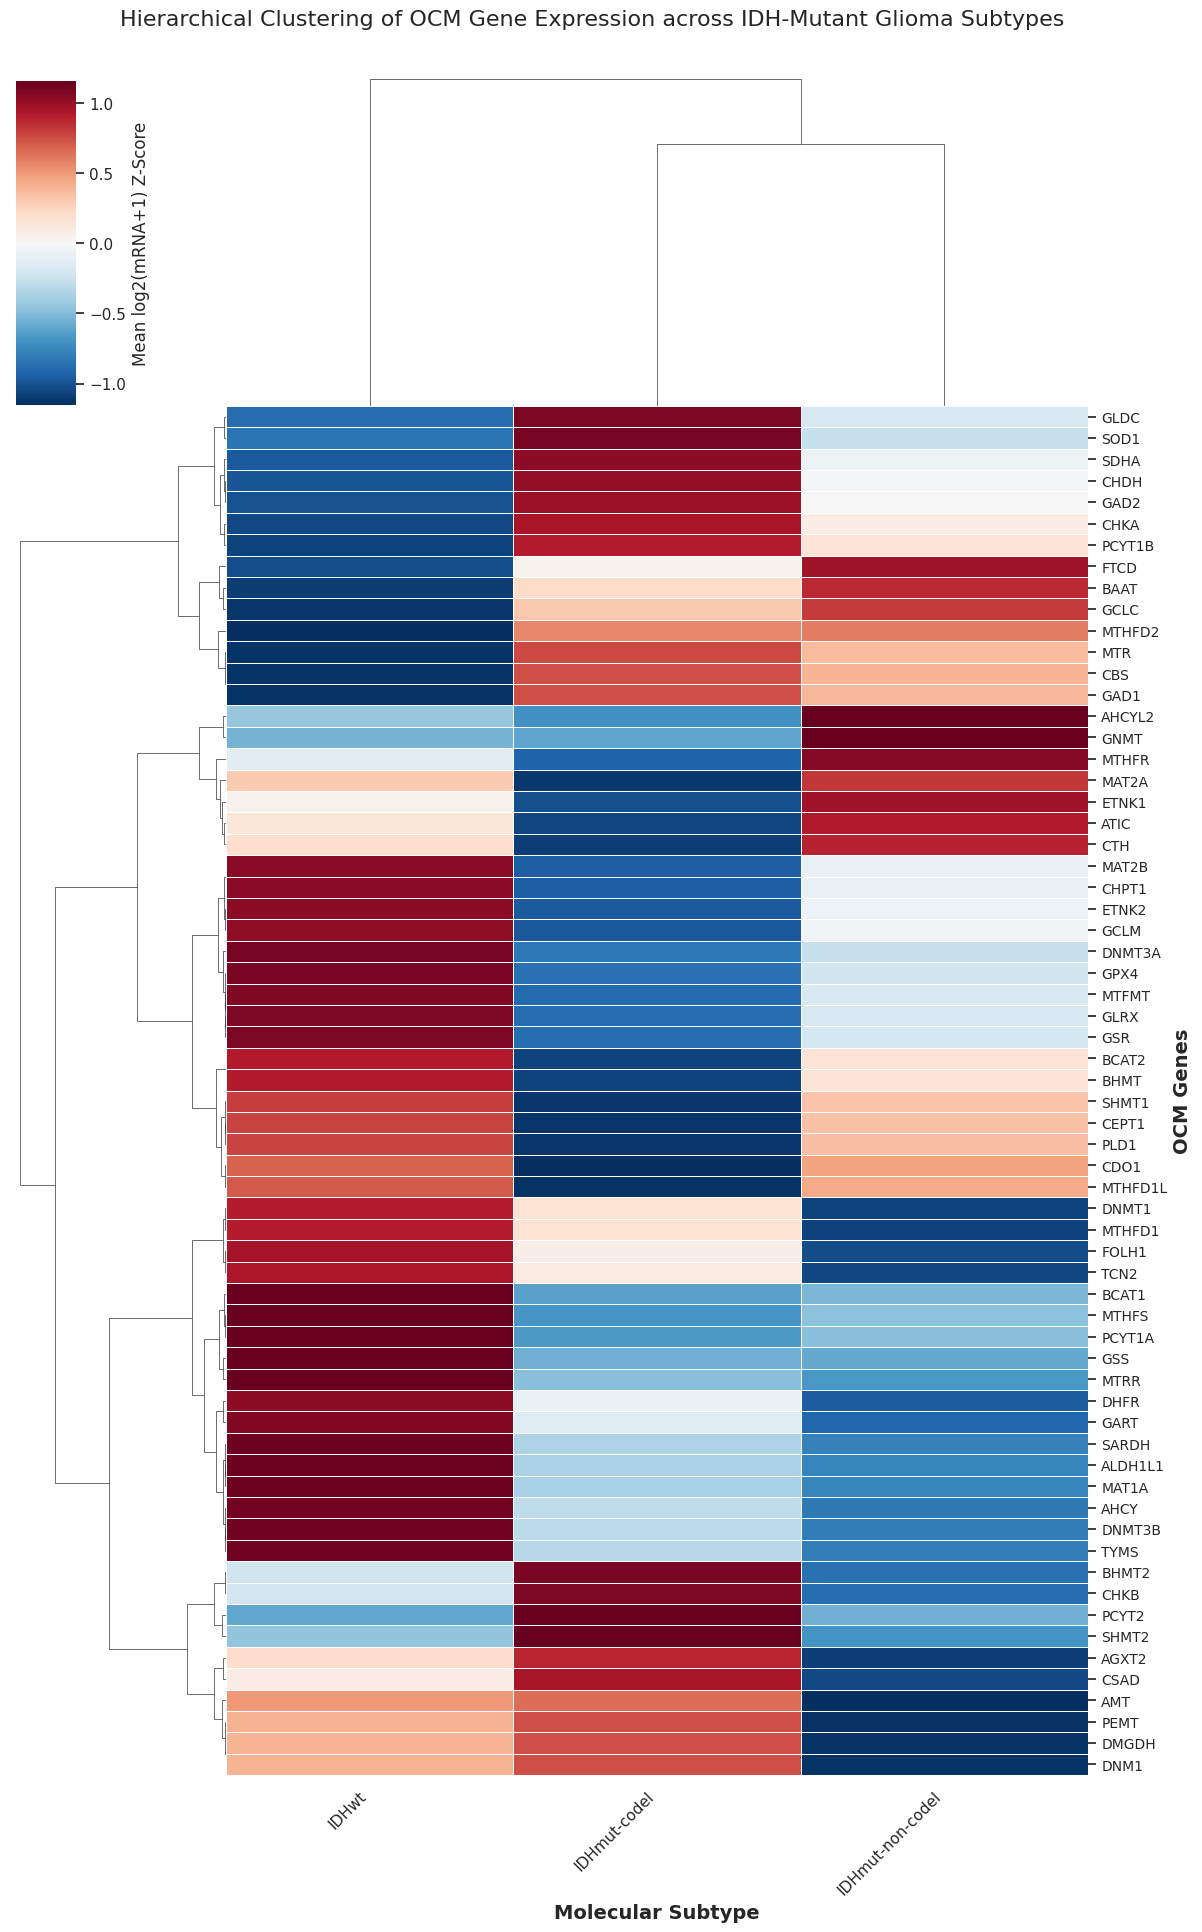

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from google.colab import drive
from functools import reduce

# --- 1. Environment Setup ---
# Mount Google Drive to access the data
drive.mount('/content/drive')

# Define the working directory
# Ensure this folder exists in your Drive and contains the 64 CSV files
folder_name = 'HeatMap TCGA'
base_path = f'/content/drive/My Drive/{folder_name}'

# Check if path exists
if not os.path.exists(base_path):
    raise FileNotFoundError(f" The folder '{base_path}' was not found. Please check the folder name in your Google Drive.")

# --- 2. Dynamic Data Loading ---
print(f"Scanning for CSV files in: {base_path}...")

# Use glob to find all CSV files in the folder (ignoring gene names)
all_files = glob.glob(os.path.join(base_path, "*.csv"))

if not all_files:
    raise ValueError("No CSV files found in the specified folder.")

print(f"Found {len(all_files)} gene files. Proceeding with data aggregation...")

data_frames = []
genes_loaded = []

# Iterate through each file found in the folder
for filename in all_files:
    try:
        # Extract gene name from the file name (assuming "GeneName.csv")
        gene_name = os.path.splitext(os.path.basename(filename))[0]

        # Read CSV
        df = pd.read_csv(filename)

        # Validate columns
        required_columns = ['Sample', 'IDH_codel.subtype', 'mRNA']
        if not all(col in df.columns for col in required_columns):
            print(f"Warning: Skipping {filename} - Missing required columns.")
            continue

        # Rename 'mRNA' column to the specific gene name for merging
        df = df.rename(columns={'mRNA': gene_name})

        # Set index for efficient merging
        df = df.set_index(['Sample', 'IDH_codel.subtype'])

        # Handle placeholders (assuming -1 indicates missing/null based on standard TCGA handling scripts)
        # Replacing -1 with NaN first to avoid incorrect log calculations
        df[gene_name] = df[gene_name].replace(-1, np.nan)

        data_frames.append(df)
        genes_loaded.append(gene_name)

    except Exception as e:
        print(f"Error processing file {filename}: {e}")

# --- 3. Data Aggregation and Preprocessing ---
if not data_frames:
    raise ValueError("No valid data frames could be loaded.")

# Concatenate all gene columns based on the Sample/Subtype index
# This aligns all genes to the correct samples
combined_df = pd.concat(data_frames, axis=1)
combined_df.reset_index(inplace=True)

# Filter for the specific molecular subtypes of interest
target_subtypes = ['IDHmut-codel', 'IDHmut-non-codel', 'IDHwt']
filtered_df = combined_df[combined_df['IDH_codel.subtype'].isin(target_subtypes)].copy()

# Fill NaN values with 0 (assuming no expression) before log transform, or drop
# Here we fill with 0 to allow log2 calculation for sparse genes
filtered_df[genes_loaded] = filtered_df[genes_loaded].fillna(0)

# Apply Log2 transformation: log2(x + 1)
# Adding 1 avoids log(0) errors
filtered_df[genes_loaded] = np.log2(filtered_df[genes_loaded] + 1)

# Group by Molecular Subtype and calculate Mean Expression
# This creates the signature profile for the heatmap
heatmap_data = filtered_df.groupby('IDH_codel.subtype')[genes_loaded].mean().T

# --- 4. Hierarchical Clustering and Heatmap Generation ---
print("Generating clustered heatmap...")

# Configure plot aesthetics
sns.set(style="white")

# Generate Clustermap
# metric='euclidean', method='ward' are standard for gene expression clustering
# z_score=0 normalizes rows (genes) to visualize relative up/down regulation
g = sns.clustermap(
    heatmap_data,
    method='ward',
    metric='euclidean',
    z_score=0,
    cmap='RdBu_r',       # Red (High) to Blue (Low)
    center=0,
    col_cluster=True,    # Cluster the subtypes
    row_cluster=True,    # Cluster the genes to show regulatory blocks
    linewidths=0.5,
    figsize=(12, 18),    # Adjusted size for 64 genes
    cbar_kws={'label': 'Mean log2(mRNA+1) Z-Score'}
)

# Adjust labels
g.ax_heatmap.set_xlabel("Molecular Subtype", fontsize=14, weight='bold')
g.ax_heatmap.set_ylabel("OCM Genes", fontsize=14, weight='bold')
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=10)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Title
g.fig.suptitle('Hierarchical Clustering of OCM Gene Expression across IDH-Mutant Glioma Subtypes', y=1.02, fontsize=16)

# --- 5. Save Output ---
output_path = os.path.join(base_path, 'OCM_Signature_Heatmap.png')
g.savefig(output_path, dpi=1200, bbox_inches='tight')

print(f"Analysis Complete. Heatmap saved to: {output_path}")
plt.show()